In [1]:
import shap
import numpy as np
from tce.model import load_model, save_model, predict
from tce.data import load_data
from tce.utils import load_json
from tce.explain import build_explainer
from pathlib import Path 
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
paths_path = PROJECT_ROOT / 'config/paths.json'
paths = load_json(paths_path)

models_dir = PROJECT_ROOT / paths['models_dir']
model_path = models_dir / paths['model']

model = load_model(model_path)

features_dir = PROJECT_ROOT / paths['data_features_dir']
train_features_path = features_dir / paths['features_train']
test_features_path = features_dir / paths['features_train']

X_train_features = load_data(train_features_path)
X_test_features = load_data(test_features_path)

In [3]:
X_train_features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7534448 stored elements and shape (25000, 436739)>

In [4]:
raw_dir = PROJECT_ROOT / paths['data_raw_dir']
test_texts_path = raw_dir / paths['raw_test']

proc_dir = PROJECT_ROOT / paths['data_processed_dir']
test_labels_path = proc_dir / paths['test_labels']

X_test = load_data(test_texts_path)
y_test = load_data(test_labels_path)

In [5]:
i = 0
example = (X_test[i], X_test_features[i], y_test[i])
example

("Once again Mr. Costner has dragged out a movie for far longer than necessary. Aside from the terrific sea rescue sequences, of which there are very few I just did not care about any of the characters. Most of us have ghosts in the closet, and Costner's character are realized early on, and then forgotten until much later, by which time I did not care. The character we should really care about is a very cocky, overconfident Ashton Kutcher. The problem is he comes off as kid who thinks he's better than anyone else around him and shows no signs of a cluttered closet. His only obstacle appears to be winning over Costner. Finally when we are well past the half way point of this stinker, Costner tells us all about Kutcher's ghosts. We are told why Kutcher is driven to be the best with no prior inkling or foreshadowing. No magic here, it was all I could do to keep from turning it off an hour in.",
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 164 stored elements and shape (

In [6]:
explainer = build_explainer(model, X_train_features)

shap_values = explainer(example[1])

tfidf = model.named_steps['tfidf']
feature_names = tfidf.get_feature_names_out()
shap_values.feature_names = feature_names.tolist()

y_pred, y_proba, _ = predict(model, example[0])
print(f'True class: {example[-1]}')
print(f'Predicted class: {y_pred[0]}')
print(f'Predicted probabilities: class 0: {y_proba[0][0]:.2f}, class 1: {y_proba[0][1]:.2f}')

True class: 0
Predicted class: 0
Predicted probabilities: class 0: 0.93, class 1: 0.07


In [7]:
artifacts_dir = PROJECT_ROOT / paths['artifacts_dir']
notebook_artifacts_dir = artifacts_dir / paths['notebooks_artifacts_dir']
waterfall_plot_path = notebook_artifacts_dir / 'waterfall_plot_example.png'

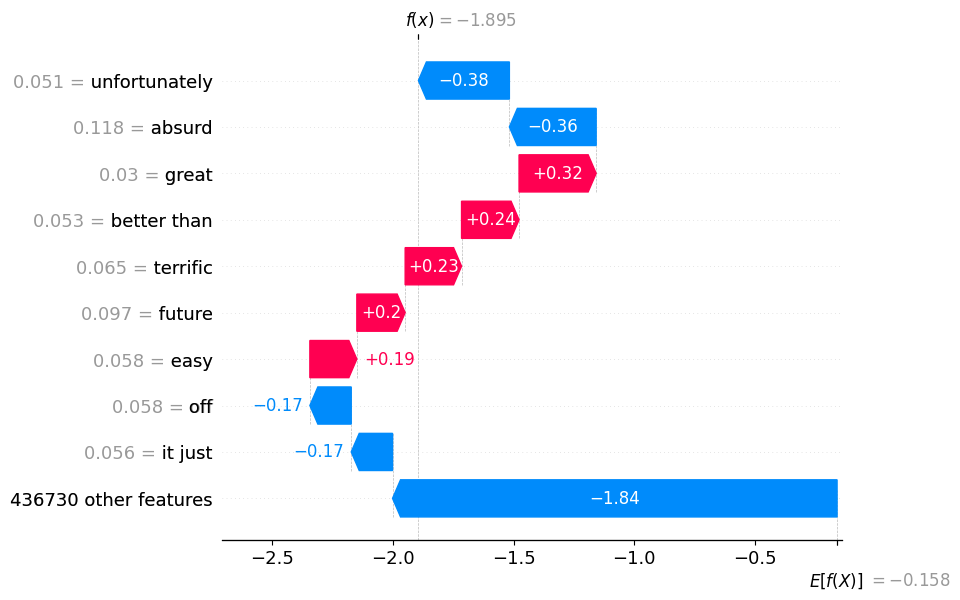

In [8]:
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=example[1],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp, show=False)
plt.savefig(waterfall_plot_path, bbox_inches='tight', dpi=300)
plt.show()

The visualization demonstrates that negative words such as "unfortunately" and "absurd" have the strongest negative impact on the prediction, outweighing positive terms like "great" and "terrific". Together with the contributions of the remaining 436 730 features, this results in an overall negative classification.

In [9]:
explainer_path = models_dir / paths['explainer']
if not explainer_path.exists():
    save_model(explainer, explainer_path)